In [1]:
!pip install thop -q

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from thop import profile
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, roc_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = ['AD', 'CN', 'MCI']
label_map = {cls: i for i, cls in enumerate(classes)}

In [2]:
base_path = '/kaggle/input/datasets/jubayerhasan755/notebook1-dataset/alzheimer'
if not os.path.exists(base_path):
    base_path = '/kaggle/input/notebook1_dataset/alzheimer'

all_paths = []
all_labels = []

for split_folder in ['train', 'test']:
    for cls in classes:
        folder_path = os.path.join(base_path, split_folder, cls)
        if os.path.exists(folder_path):
            for img in os.listdir(folder_path):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_paths.append(os.path.join(folder_path, img))
                    all_labels.append(label_map[cls])

train_files, test_files, train_labels, test_labels = train_test_split(
    all_paths, all_labels, train_size=0.9, stratify=all_labels, random_state=42
)

t_files, v_files, t_labels, v_labels = train_test_split(
    train_files, train_labels, test_size=0.1, stratify=train_labels, random_state=42
)

class AlzheimerDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(AlzheimerDataset(t_files, t_labels, transform), batch_size=32, shuffle=True)
val_loader = DataLoader(AlzheimerDataset(v_files, v_labels, transform), batch_size=32)
test_loader = DataLoader(AlzheimerDataset(test_files, test_labels, transform), batch_size=32)

print(f"Total: {len(all_paths)} | Train: {len(t_files)} | Val: {len(v_files)} | Test: {len(test_files)}")

Total: 5154 | Train: 4174 | Val: 464 | Test: 516


In [3]:
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

dummy_in = torch.randn(1, 3, 224, 224).to(device)
macs, params = profile(model, inputs=(dummy_in, ), verbose=False)
gflops = (macs * 2) / 1e9

print(f"Input Size: 224x224 | GFLOPs: {gflops:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


Input Size: 224x224 | GFLOPs: 8.2634


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses = []
val_losses = []

start_train = time.time()
for epoch in range(50):
    model.train()
    running_loss = 0.0
    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for imgs, labs in val_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            v_loss += criterion(model(imgs), labs).item()
    
    avg_val_loss = v_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/50] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

train_wall_time = time.time() - start_train
print(f"\nTotal Training Time: {train_wall_time:.2f} seconds")

Epoch [1/50] | Train Loss: 0.2717 | Val Loss: 0.1548
Epoch [2/50] | Train Loss: 0.0448 | Val Loss: 0.0482
Epoch [3/50] | Train Loss: 0.0177 | Val Loss: 0.0329
Epoch [4/50] | Train Loss: 0.0377 | Val Loss: 0.0603
Epoch [5/50] | Train Loss: 0.0280 | Val Loss: 0.0087
Epoch [6/50] | Train Loss: 0.0070 | Val Loss: 0.0131
Epoch [7/50] | Train Loss: 0.0334 | Val Loss: 0.0325
Epoch [8/50] | Train Loss: 0.0107 | Val Loss: 0.0518
Epoch [9/50] | Train Loss: 0.0153 | Val Loss: 0.0424
Epoch [10/50] | Train Loss: 0.0226 | Val Loss: 0.0118
Epoch [11/50] | Train Loss: 0.0060 | Val Loss: 0.0069
Epoch [12/50] | Train Loss: 0.0015 | Val Loss: 0.0004
Epoch [13/50] | Train Loss: 0.0011 | Val Loss: 0.0046
Epoch [14/50] | Train Loss: 0.0003 | Val Loss: 0.0002
Epoch [15/50] | Train Loss: 0.0005 | Val Loss: 0.0001
Epoch [16/50] | Train Loss: 0.0002 | Val Loss: 0.0001
Epoch [17/50] | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch [18/50] | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch [19/50] | Train Loss: 0.0001 | 

In [5]:
model.eval()
y_true, y_pred, y_prob = [], [], []
start_test = time.time()
with torch.no_grad():
    for imgs, labs in test_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        out = model(imgs)
        y_prob.extend(torch.softmax(out, dim=1).cpu().numpy())
        y_pred.extend(torch.argmax(out, dim=1).cpu().numpy())
        y_true.extend(labs.cpu().numpy())
test_wall_time = time.time() - start_test

acc = accuracy_score(y_true, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
auc = roc_auc_score(y_true, y_prob, multi_class='ovr')

print(f"Accuracy: {acc:.4f}\nPrecision: {p:.4f}\nRecall: {r:.4f}\nF1: {f1:.4f}\nAUC: {auc:.4f}\nTest Time: {test_wall_time:.2f}s")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
AUC: 1.0000
Test Time: 4.71s


Accuracy for AD: 1.0000
Accuracy for CN: 1.0000
Accuracy for MCI: 1.0000


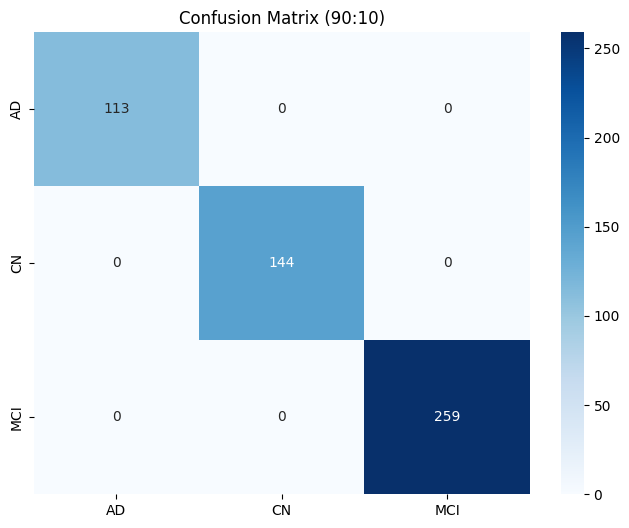

In [6]:
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for i, cls in enumerate(classes):
    print(f"Accuracy for {cls}: {per_class_acc[i]:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix (90:10)')
plt.show()

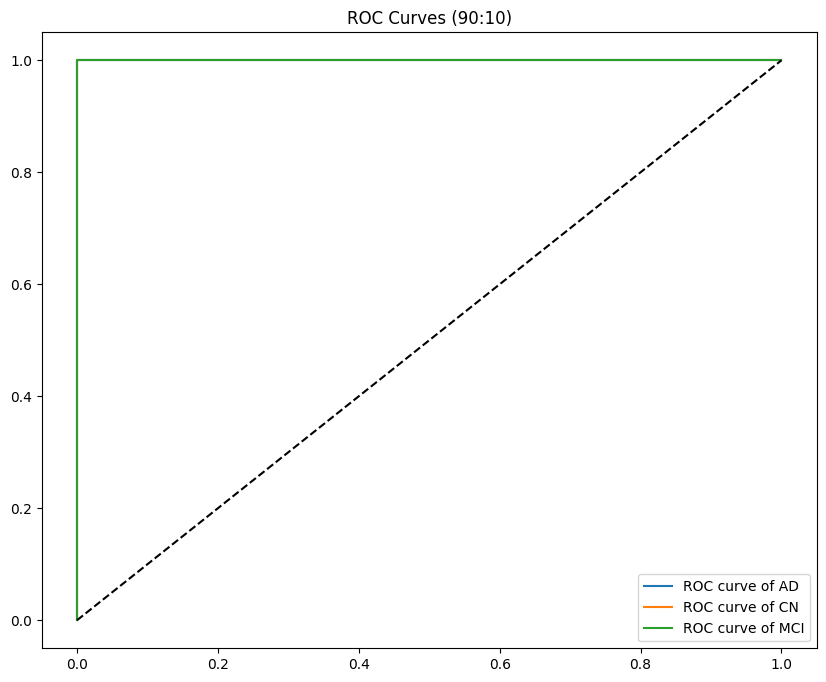

In [7]:
plt.figure(figsize=(10, 8))
y_prob_arr = np.array(y_prob)
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_true, y_prob_arr[:, i], pos_label=i)
    plt.plot(fpr, tpr, label=f'ROC curve of {classes[i]}')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves (90:10)')
plt.legend()
plt.show()